### Hypothesis Testing

* Perform hypothesis testing on the entire dataset
* Purpose is for data understanding, checking distributional assumptions, feature-target relationships, multicollinearity, etc

### Steps
* First hypothesis testing
* train/test split
* fit scalers on training data only, apply to both splits
* model

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('data/stevenhan_with_features.csv')

In [4]:
df.head()

,game_id,move_number,color,username,move,time_control,increment_sec,time_left_cs,time_left_sec,time_spent_cs,...,is_blunder,eval_unified,eval_volatility_norm,time_pressure_norm,complexity_material_norm,material_time_pressure_int,time_eval_volatility_int,move_number_norm,cumulative_time_pressure,late_endgame_int
0,04ELJhAC,1,black,stevenhan,d5,10+10,10,60003.0,600.03,0.0,...,0,32.0,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.0
1,04ELJhAC,2,black,stevenhan,c6,10+10,10,58795.0,587.95,2208.0,...,0,23.0,0.000000,0.020083,1.0,0.020083,0.000000,0.016949,0.567268,0.0
2,04ELJhAC,3,black,stevenhan,Nf6,10+10,10,59267.0,592.67,528.0,...,0,17.0,0.021332,0.012217,1.0,0.012217,0.000261,0.033898,0.468613,0.0
3,04ELJhAC,4,black,stevenhan,Bg4,10+10,10,59731.0,597.31,536.0,...,0,24.0,0.010697,0.004483,1.0,0.004483,0.000048,0.050847,0.420313,0.0
4,04ELJhAC,5,black,stevenhan,Nbd7,10+10,10,60563.0,605.63,168.0,...,0,16.0,0.012316,0.000000,1.0,0.000000,0.000000,0.067797,0.353515,0.0


In [5]:
df.shape

(1901, 58)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1901 entries, 0 to 1900
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   game_id                     1901 non-null   str    
 1   move_number                 1901 non-null   int64  
 2   color                       1901 non-null   str    
 3   username                    1901 non-null   str    
 4   move                        1901 non-null   str    
 5   time_control                1901 non-null   str    
 6   increment_sec               1901 non-null   int64  
 7   time_left_cs                1901 non-null   float64
 8   time_left_sec               1901 non-null   float64
 9   time_spent_cs               1901 non-null   float64
 10  time_spent_sec              1901 non-null   float64
 11  time_left_ratio             1901 non-null   float64
 12  time_spent_ratio            1901 non-null   float64
 13  eval                        1790 non-null   

Drop the columns I don't need

In [ ]:
df = df.drop([ 'username', 'move', 'time_left_cs', 'time_spent_cs', 'best_move',
       'variation', 'judgment', 'prev_eval',
       'eval_change', 'eval_loss'], axis = 1)

In [8]:
df.shape

(1901, 48)

In [9]:
df.dtypes

game_id                           str
move_number                     int64
color                             str
time_control                      str
increment_sec                   int64
time_left_sec                 float64
time_spent_sec                float64
time_left_ratio               float64
time_spent_ratio              float64
eval                          float64
mate                          float64
eval_volatility               float64
pieces_remaining                int64
material_density              float64
num_minor_pieces                int64
num_rooks                       int64
num_queens                      int64
num_pawns                       int64
complexity_material_score       int64
white_castled_king              int64
white_castled_queen             int64
black_castled_king              int64
black_castled_queen             int64
queen_present                   int64
is_opening                      int64
is_middlegame                   int64
is_endgame  

Check for columns with string

In [10]:
[col for col in df.columns if df[col].dtype == 'str']

['game_id', 'color', 'time_control']

In [11]:
df['color'].unique()

<StringArray>
['black', 'white']
Length: 2, dtype: str

In [12]:
df['time_control'].unique()

<StringArray>
['10+10', '10+5', '10+0', '10+1', '10+2', '15+10', '90+30', '13+7']
Length: 8, dtype: str

One hot encode these columns

In [13]:
df = pd.get_dummies(df, columns=['color'],drop_first=True, dtype=int)

In [14]:
df = pd.get_dummies(df, columns=['time_control'],drop_first=True, dtype=int)

In [15]:
df.head()

,game_id,move_number,increment_sec,time_left_sec,time_spent_sec,time_left_ratio,time_spent_ratio,eval,mate,eval_volatility,...,cumulative_time_pressure,late_endgame_int,color_white,time_control_10+1,time_control_10+10,time_control_10+2,time_control_10+5,time_control_13+7,time_control_15+10,time_control_90+30
0,04ELJhAC,1,10,600.03,0.00,1.000050,0.000000,32.0,NaN,NaN,...,0.000000,0.0,0,0,1,0,0,0,0,0
1,04ELJhAC,2,10,587.95,22.08,0.979917,1.134536,23.0,NaN,NaN,...,0.567268,0.0,0,0,1,0,0,0,0,0
2,04ELJhAC,3,10,592.67,5.28,0.987783,0.271302,17.0,NaN,6.164414,...,0.468613,0.0,0,0,1,0,0,0,0,0
3,04ELJhAC,4,10,597.31,5.36,0.995517,0.275413,24.0,NaN,3.091206,...,0.420313,0.0,0,0,1,0,0,0,0,0
4,04ELJhAC,5,10,605.63,1.68,1.009383,0.086323,16.0,NaN,3.559026,...,0.353515,0.0,0,0,1,0,0,0,0,0


Density plot for move number

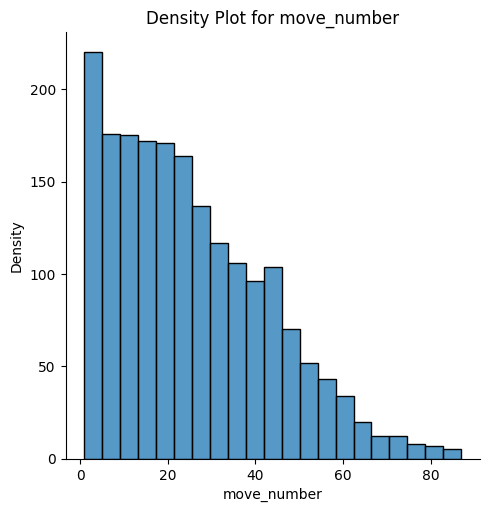

In [ ]:
sns.displot(df['move_number'])

plt.title('Density Plot for move_number')
plt.xlabel('move_number')
plt.ylabel('Density')

plt.show()

Density plot for Eval

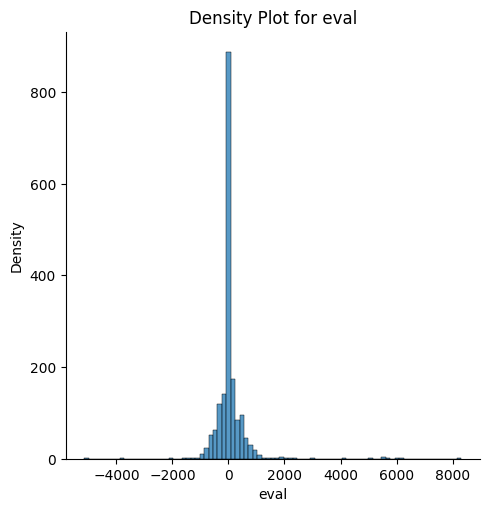

In [ ]:
sns.displot(df['eval'])

plt.title('Density Plot for eval')
plt.xlabel('eval')
plt.ylabel('Density')

plt.show()

Density plot for Eval Unified

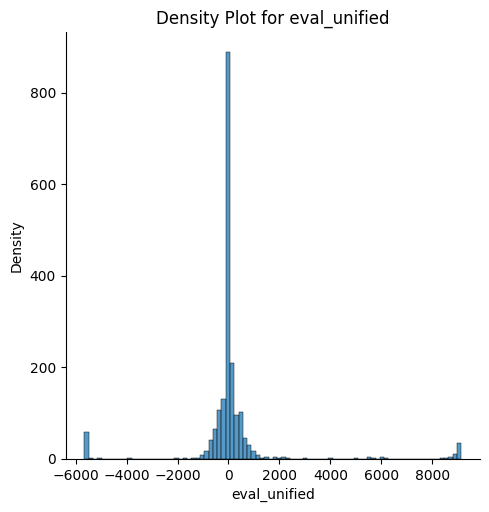

In [ ]:
sns.displot(df['eval_unified'])

plt.title('Density Plot for eval_unified')
plt.xlabel('eval_unified')
plt.ylabel('Density')

plt.show()

Density plot for mate

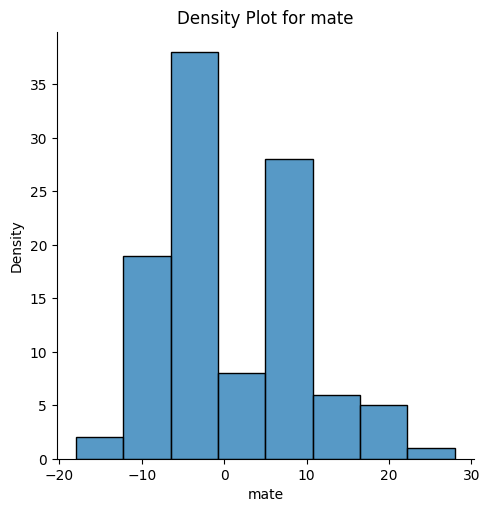

In [ ]:
sns.displot(df['mate'])

plt.title('Density Plot for mate')
plt.xlabel('mate')
plt.ylabel('Density')

plt.show()

Density plot for time_spent_sec

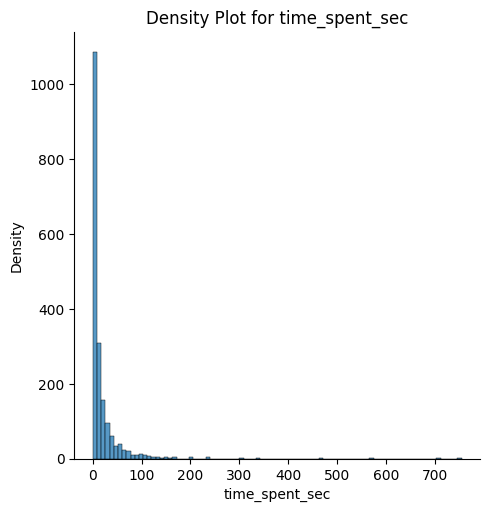

In [ ]:
sns.displot(df['time_spent_sec'])

plt.title('Density Plot for time_spent_sec')
plt.xlabel('time_spent_sec')
plt.ylabel('Density')

plt.show()

Density plot for eval_volatility

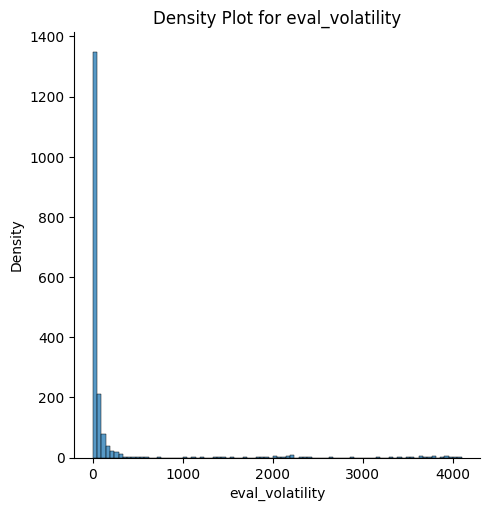

In [ ]:
sns.displot(df['eval_volatility'])

plt.title('Density Plot for eval_volatility')
plt.xlabel('eval_volatility')
plt.ylabel('Density')

plt.show()

Density plot for avg_time_spent_per_move

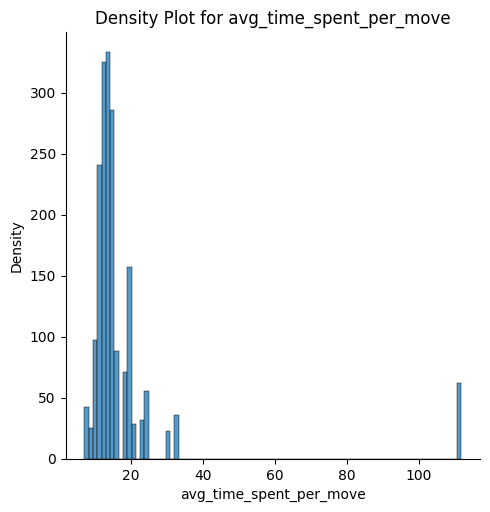

In [ ]:
sns.displot(df['avg_time_spent_per_move'])

plt.title('Density Plot for avg_time_spent_per_move')
plt.xlabel('avg_time_spent_per_move')
plt.ylabel('Density')

plt.show()

Density plot for time_pressure_norm

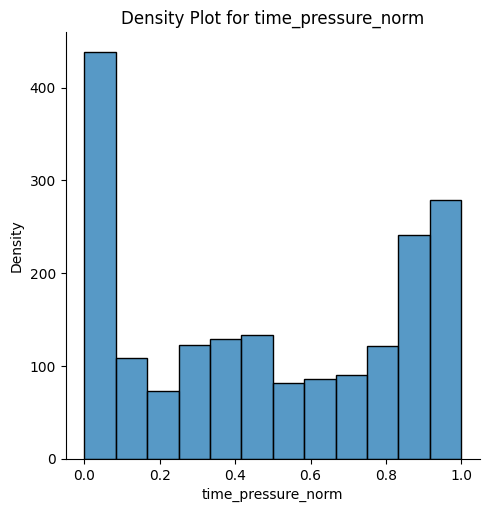

In [ ]:
sns.displot(df['time_pressure_norm'])

plt.title('Density Plot for time_pressure_norm')
plt.xlabel('time_pressure_norm')
plt.ylabel('Density')

plt.show()

Density plot for material_time_pressure_int

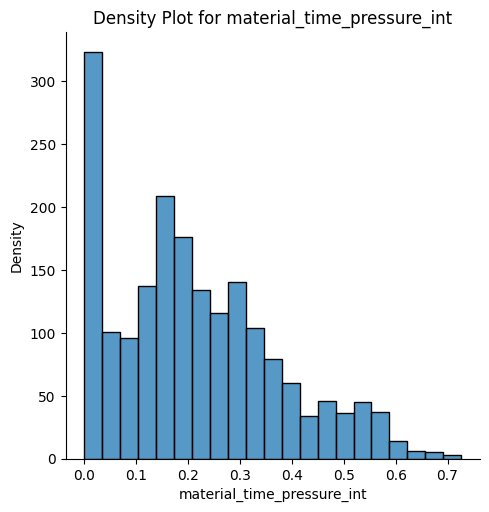

In [ ]:
sns.displot(df['material_time_pressure_int'])

plt.title('Density Plot for material_time_pressure_int')
plt.xlabel('material_time_pressure_int')
plt.ylabel('Density')

plt.show()

Density plot for cumulative_time_pressure

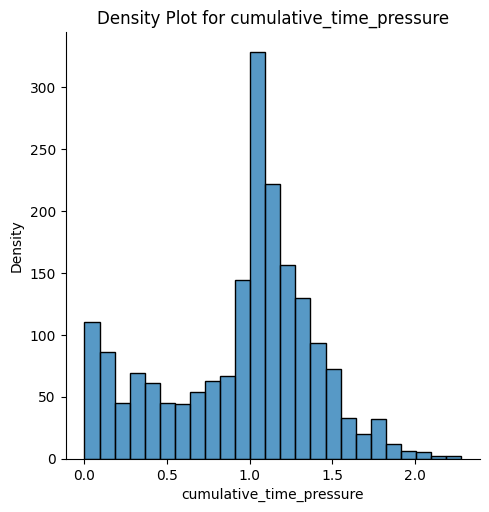

In [ ]:
sns.displot(df['cumulative_time_pressure'])

plt.title('Density Plot for cumulative_time_pressure')
plt.xlabel('cumulative_time_pressure')
plt.ylabel('Density')

plt.show()

Density plot for late_endgame_int  

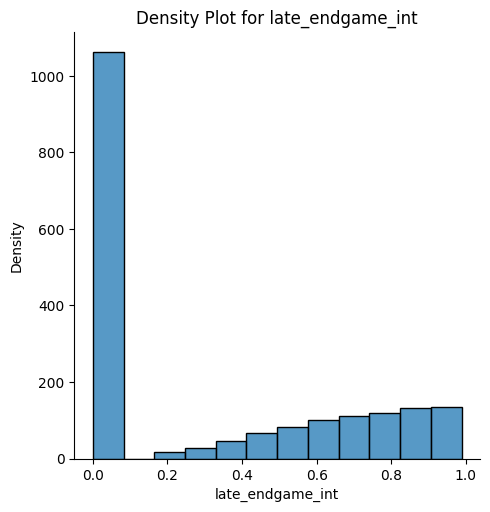

In [ ]:
sns.displot(df['late_endgame_int'])

plt.title('Density Plot for late_endgame_int')
plt.xlabel('late_endgame_int')
plt.ylabel('Density')

plt.show()

When are there 'impossible' values where time spent is greater than time left

In [27]:
df[df['time_spent_sec'] > df['time_left_sec']]

,game_id,move_number,increment_sec,time_left_sec,time_spent_sec,time_left_ratio,time_spent_ratio,eval,mate,eval_volatility,...,cumulative_time_pressure,late_endgame_int,color_white,time_control_10+1,time_control_10+10,time_control_10+2,time_control_10+5,time_control_13+7,time_control_15+10,time_control_90+30
26,04ELJhAC,27,10,67.63,95.92,0.112717,4.928656,269.0,NaN,24.390344,...,1.507995,0.000000,0,0,1,0,0,0,0,0
29,04ELJhAC,30,10,25.07,38.40,0.041783,1.973107,333.0,NaN,34.296096,...,1.481474,0.000000,0,0,1,0,0,0,0,0
31,04ELJhAC,32,10,13.39,31.68,0.022317,1.627813,1182.0,NaN,401.168571,...,1.439751,0.525424,0,0,1,0,0,0,0,0
33,04ELJhAC,34,10,14.11,15.84,0.023517,0.813907,5663.0,NaN,2191.425766,...,1.384197,0.559322,0,0,1,0,0,0,0,0
40,04ELJhAC,41,10,11.95,17.20,0.019917,0.883787,5471.0,NaN,1705.501946,...,1.238305,0.677966,0,0,1,0,0,0,0,0
45,04ELJhAC,46,10,12.35,18.16,0.020583,0.933115,NaN,2.0,3290.470306,...,1.159111,0.762712,0,0,1,0,0,0,0,0
56,04ELJhAC,57,10,28.83,42.40,0.048050,2.178639,NaN,21.0,2885.668504,...,1.019727,0.949153,0,0,1,0,0,0,0,0
87,3gJzIPyt,29,5,49.23,56.68,0.082050,3.979493,439.0,NaN,106.417417,...,1.672447,0.000000,0,0,0,0,1,0,0,0
213,9aF3VV33,24,5,58.99,104.20,0.098317,4.265248,-776.0,NaN,160.787645,...,1.118911,0.821429,1,0,0,0,1,0,0,0
294,APtuyYz1,46,5,20.99,50.12,0.034983,3.774985,813.0,NaN,227.834735,...,1.316509,0.703125,0,0,0,0,1,0,0,0


In [28]:
df.shape

(1901, 54)

Cap time_spent_sec to time_left_sec where violated

In [ ]:
mask = df['time_spent_sec'] > df['time_left_sec']
df.loc[mask, 'time_spent_sec'] = df.loc[mask, 'time_left_sec']

Recalculate time_spent_ratio after capping

In [ ]:
df.loc[mask, 'time_spent_ratio'] = (
    df.loc[mask, 'time_spent_sec'] / df.loc[mask, 'time_left_sec'].replace(0, np.nan)
).fillna(0)

In [30]:
df[df['time_spent_sec'] > df['time_left_sec']]

,game_id,move_number,increment_sec,time_left_sec,time_spent_sec,time_left_ratio,time_spent_ratio,eval,mate,eval_volatility,...,cumulative_time_pressure,late_endgame_int,color_white,time_control_10+1,time_control_10+10,time_control_10+2,time_control_10+5,time_control_13+7,time_control_15+10,time_control_90+30


Describe the target features

In [31]:
df[['is_inaccuracy', 'is_mistake', 'is_blunder']].describe()

,is_inaccuracy,is_mistake,is_blunder
count,1901.000000,1901.000000,1901.000000
mean,0.035245,0.010521,0.019989
std,0.184446,0.102057,0.140001
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000


Observations
* About 3.5% of moves are inaccuracy
* About 1% of moves are mistake
* About 2% of moves are blunder

Create game phase label for easier grouping

In [ ]:
df['game_phase'] = 'Unknown'
df.loc[df['is_opening'] == 1, 'game_phase'] = 'Opening'
df.loc[df['is_middlegame'] == 1, 'game_phase'] = 'Middlegame'
df.loc[df['is_endgame'] == 1, 'game_phase'] = 'Endgame'

Compute statistics for each phase

In [34]:
phase_stats = df.groupby('game_phase').agg({
    'is_blunder': ['sum', 'mean'],
    'is_mistake': ['sum', 'mean'],
    'is_inaccuracy': ['sum', 'mean'],
    'move_number': 'count'
}).round(4)

phase_stats.columns = ['Blunders_Count', 'Blunder_Rate', 
                       'Mistakes_Count', 'Mistake_Rate',
                       'Inaccuracies_Count', 'Inaccuracy_Rate',
                       'Total_Moves']

print(phase_stats)

            Blunders_Count  Blunder_Rate  Mistakes_Count  Mistake_Rate  \
game_phase                                                               
Endgame                 32        0.0381               7        0.0083   
Middlegame               6        0.0088              10        0.0146   
Opening                  0        0.0000               3        0.0080   

            Inaccuracies_Count  Inaccuracy_Rate  Total_Moves  
game_phase                                                    
Endgame                     32           0.0381          840  
Middlegame                  33           0.0482          684  
Opening                      2           0.0053          377  


Observations
* biggest shift in eval (blunders), occur most predominantely in endgame. 
* opening has least potential for any type of error
* middlegame has most inaccuracies, folllowed by mistakes then blunders least likley

Chi square test to determine if categorical vars significantly related

In [ ]:
from scipy.stats import chi2_contingency

def test_chi_square(df, error_col, error_name):
    observed = pd.crosstab(df['game_phase'], df[error_col])
    chi2, p, dof, expected = chi2_contingency(observed)
    n = observed.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * min(observed.shape[0]-1, observed.shape[1]-1)))
    
    return {
        'Error_Type': error_name,
        'Chi2': chi2,
        'P_value': p,
        'DOF': dof,
        'Cramers_V': cramers_v,
        'Significant': 'yes' if p < 0.05 else 'no'
    }

# Run all tests
test_results = []
for col, name in [('is_inaccuracy', 'Inaccuracy'), 
                   ('is_mistake', 'Mistake'),
                   ('is_blunder', 'Blunder')]:
    test_results.append(test_chi_square(df, col, name))

results_df = pd.DataFrame(test_results)
print(results_df.to_string(index=False))

Error_Type      Chi2  P_value  DOF  Cramers_V Significant
Inaccuracy 13.539452 0.001148    2   0.084394         yes
   Mistake  1.728061 0.421460    2   0.030150          no
   Blunder 26.139949 0.000002    2   0.117263         yes


Cramer's V association
* 0.00–0.10: Weak association
* 0.10–0.30: Moderate association
* 0.30–0.50: Strong association

Observations
* Inaccuracies: statistically significant- meaning inaccuracies are not evenly distributed across game phase, but weak correlation
* mistake: Game phase has no meaningful relationship with mistake rate
* Blunders are significantly concentrated in certain game phases

Define Time Bins on time_left_ratio to determine severity

In [ ]:
def create_time_bins(df):
    bins = [-np.inf, 0.05, 0.20, 0.50, np.inf]
    labels = ['Severe (<5%)', 'Low (5-20%)', 'Moderate (20-50%)', 'High (>50%)']
    
    df['time_bin'] = pd.cut(
        df['time_left_ratio'], 
        bins=bins, 
        labels=labels,
        include_lowest=True
    )
    
    return df

df = create_time_bins(df)

Display bin distribution

In [ ]:
bin_counts = df['time_bin'].value_counts().sort_index()
print(bin_counts)

time_bin
Severe (<5%)          189
Low (5-20%)           384
Moderate (20-50%)     325
High (>50%)          1003
Name: count, dtype: int64


Calculate the error rates by time bin

In [ ]:
error_rates = df.groupby('time_bin').agg({
    'is_inaccuracy': ['sum', 'mean'],
    'is_mistake': ['sum', 'mean'],
    'is_blunder': ['sum', 'mean'],
    'move_number': 'count'
}).round(4)

error_rates.columns = [
    'Inaccuracy_Count', 'Inaccuracy_Rate',
    'Mistake_Count', 'Mistake_Rate',
    'Blunder_Count', 'Blunder_Rate',
    'Total_Moves'
]

print("\n", error_rates)

# Convert rates to percentages for display
rates_pct = error_rates.copy()
for col in ['Inaccuracy_Rate', 'Mistake_Rate', 'Blunder_Rate']:
    rates_pct[col] = rates_pct[col] * 100

print("\nError Rates (%) by Time Bin")
print(rates_pct[['Inaccuracy_Rate', 'Mistake_Rate', 'Blunder_Rate', 'Total_Moves']].round(2))



                    Inaccuracy_Count  Inaccuracy_Rate  Mistake_Count  \
time_bin                                                              
Severe (<5%)                     11           0.0582              2   
Low (5-20%)                      17           0.0443              4   
Moderate (20-50%)                16           0.0492              7   
High (>50%)                      23           0.0229              7   

                   Mistake_Rate  Blunder_Count  Blunder_Rate  Total_Moves  
time_bin                                                                   
Severe (<5%)             0.0106              9        0.0476          189  
Low (5-20%)              0.0104             17        0.0443          384  
Moderate (20-50%)        0.0215              8        0.0246          325  
High (>50%)              0.0070              4        0.0040         1003  

Error Rates (%) by Time Bin
                   Inaccuracy_Rate  Mistake_Rate  Blunder_Rate  Total_Moves
time_bin  

Perform chi square test on error types vs time left

In [ ]:
def chi_square_time_test(df, error_column, error_name):
    # Create contingency table
    contingency_table = pd.crosstab(
        df['time_bin'], 
        df[error_column],
        margins=True
    )
    
    print(f"\nTEST: {error_name} vs Time Pressure")
    
    print(f"\nContingency Table:")
    print(contingency_table)
    
    # Get table without margins for chi-square test
    observed = pd.crosstab(df['time_bin'], df[error_column])
    
    # Perform chi-square test
    chi2, p_value, dof, expected = chi2_contingency(observed)
    
    print(f"\nChi-Square Test Results")
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"P-value: {p_value:.6f}")
    print(f"Degrees of freedom: {dof}")
    
    # Interpret results
    alpha = 0.05
    print(f"\nSignificance level: {alpha}")
    
    if p_value < alpha:
        print(f"REJECT null hypothesis: (p = {p_value:.6f} < {alpha})")
        print(f"Conclusion: {error_name} probability DOES differ by time pressure")
        print(f"The relationship is statistically significant.")
    else:
        print(f"FAIL TO REJECT null hypothesis (p = {p_value:.6f} >= {alpha})")
        print(f"Conclusion: {error_name} probability is independent of time pressure")
        print(f"No significant relationship detected.")
    
    # Calculate effect size
    n = observed.sum().sum()
    min_dim = min(observed.shape[0] - 1, observed.shape[1] - 1)
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    
    print(f"\nEffect Size: {cramers_v:.4f}")
    if cramers_v < 0.1:
        effect = "negligible"
    elif cramers_v < 0.3:
        effect = "small"
    elif cramers_v < 0.5:
        effect = "medium"
    else:
        effect = "large"
    print(f"  Interpretation: {effect} effect")
    
    return {
        'chi2': chi2,
        'p_value': p_value,
        'dof': dof,
        'cramers_v': cramers_v,
        'significant': p_value < alpha
    }

# Perform tests for each error type
results = {}
results['inaccuracy'] = chi_square_time_test(df, 'is_inaccuracy', 'Inaccuracy')
results['mistake'] = chi_square_time_test(df, 'is_mistake', 'Mistake')
results['blunder'] = chi_square_time_test(df, 'is_blunder', 'Blunder')


TEST: Inaccuracy vs Time Pressure

Contingency Table:
is_inaccuracy         0   1   All
time_bin                         
Severe (<5%)        178  11   189
Low (5-20%)         367  17   384
Moderate (20-50%)   309  16   325
High (>50%)         980  23  1003
All                1834  67  1901

Chi-Square Test Results
Chi-square statistic: 10.1915
P-value: 0.017006
Degrees of freedom: 3

Significance level: 0.05
REJECT null hypothesis: (p = 0.017006 < 0.05)
Conclusion: Inaccuracy probability DOES differ by time pressure
The relationship is statistically significant.

Effect Size: 0.0732
  Interpretation: negligible effect

TEST: Mistake vs Time Pressure

Contingency Table:
is_mistake            0   1   All
time_bin                         
Severe (<5%)        187   2   189
Low (5-20%)         380   4   384
Moderate (20-50%)   318   7   325
High (>50%)         996   7  1003
All                1881  20  1901

Chi-Square Test Results
Chi-square statistic: 4.9988
P-value: 0.171886
Degrees of

Observations
* Inaccuracy probability DOES differ by time pressure
* The relationship is statistically significant.

* Mistake probability is independent of time pressure
* No significant relationship detected.

* Blunder probability DOES differ by time pressure
* The relationship is statistically significant With a small effect

Test for Monotonicity 

In [ ]:
# Order bins from high time to low time
ordered_bins = ['High (>50%)', 'Moderate (20-50%)', 'Low (5-20%)', 'Severe (<5%)']

print("\nChecking if error rates increase monotonically as time pressure increases:")
print("(Expected: Error rates should increase from High → Severe)\n")

for error_type in ['Blunder', 'Mistake', 'Inaccuracy']:
    error_col = f'is_{error_type.lower().replace(" ", "_")}'
    
    rates_by_bin = df.groupby('time_bin')[error_col].mean()
    rates_ordered = [rates_by_bin.get(bin_name, 0) for bin_name in ordered_bins if bin_name in rates_by_bin.index]
    
    # Check if monotonically increasing
    is_monotonic = all(rates_ordered[i] <= rates_ordered[i+1] for i in range(len(rates_ordered)-1))
    
    print(f"{error_type}:")
    for i, bin_name in enumerate([b for b in ordered_bins if b in rates_by_bin.index]):
        print(f"  {bin_name}: {rates_ordered[i]*100:.2f}%")
    
    if is_monotonic:
        print(f"Monotonically increasing (as expected)")
    else:
        print(f"NOT monotonically increasing")
    print()


Checking if error rates increase monotonically as time pressure increases:
(Expected: Error rates should increase from High → Severe)

Blunder:
  High (>50%): 0.40%
  Moderate (20-50%): 2.46%
  Low (5-20%): 4.43%
  Severe (<5%): 4.76%
Monotonically increasing (as expected)

Mistake:
  High (>50%): 0.70%
  Moderate (20-50%): 2.15%
  Low (5-20%): 1.04%
  Severe (<5%): 1.06%
NOT monotonically increasing

Inaccuracy:
  High (>50%): 2.29%
  Moderate (20-50%): 4.92%
  Low (5-20%): 4.43%
  Severe (<5%): 5.82%
NOT monotonically increasing



Observations
* Blunder and inaccuracy are mostly monotonically increasing, greatest trend for blunder
* for mistake is less of a trend. 

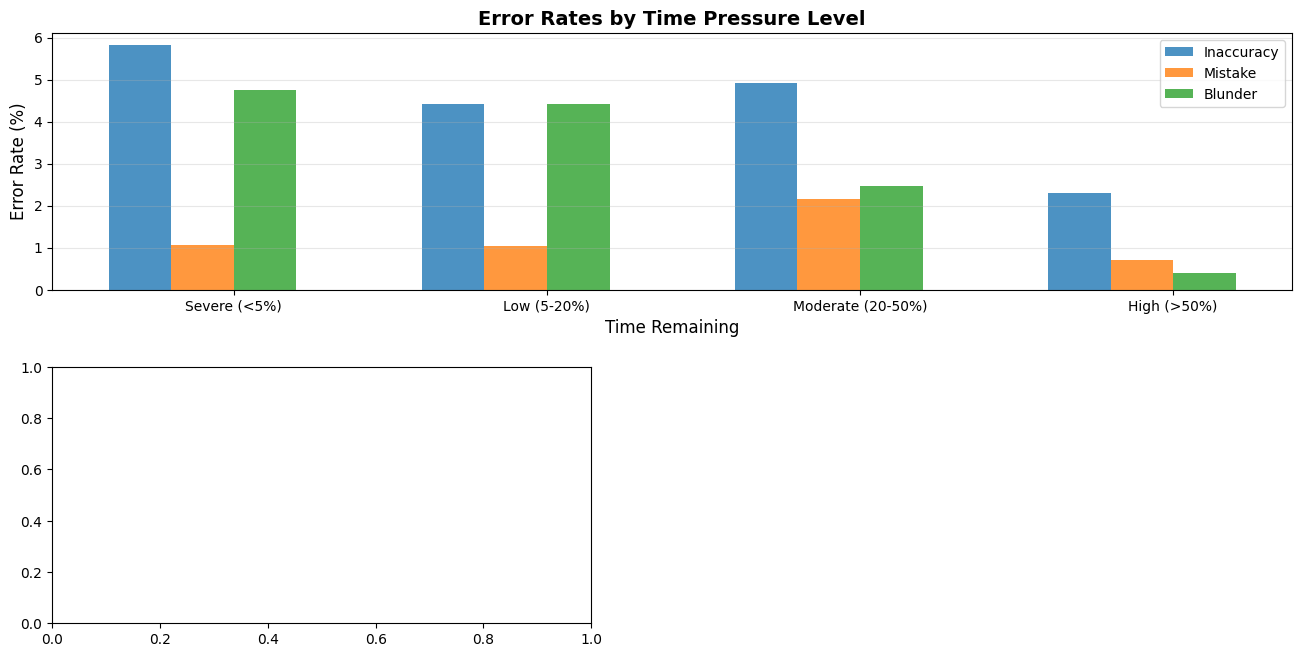

In [46]:
#Visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1: Error rates by time bin (bar chart)
ax1 = fig.add_subplot(gs[0, :])
plot_data = rates_pct[['Blunder_Rate', 'Mistake_Rate', 'Inaccuracy_Rate']].reset_index()
plot_data['time_bin'] = plot_data['time_bin'].astype(str)

x = np.arange(len(plot_data))
width = 0.2

bars1 = ax1.bar(x - width*1.5, plot_data['Inaccuracy_Rate'], width, label='Inaccuracy', alpha=0.8)
bars2 = ax1.bar(x - width*0.5, plot_data['Mistake_Rate'], width, label='Mistake', alpha=0.8)
bars3 = ax1.bar(x + width*0.5, plot_data['Blunder_Rate'], width, label='Blunder', alpha=0.8)

ax1.set_xlabel('Time Remaining', fontsize=12)
ax1.set_ylabel('Error Rate (%)', fontsize=12)
ax1.set_title('Error Rates by Time Pressure Level', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(plot_data['time_bin'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2-5: Individual error type trends (monotonicity check)
error_types = [
    ('is_blunder', 'Blunder Rate', 'red'),
    ('is_mistake', 'Mistake Rate', 'orange'),
    ('is_inaccuracy', 'Inaccuracy Rate', 'gold')
]

for idx, (error_col, title, color) in enumerate(error_types):
    ax = fig.add_subplot(gs[(idx//2)+1, idx%2])
    
    # Get rates in order from high time to low time
    rates_by_bin = df.groupby('time_bin')[error_col].mean() * 100
    
    # Reorder for plotting
    plot_bins = [b for b in ordered_bins if b in rates_by_bin.index]
    plot_rates = [rates_by_bin[b] for b in plot_bins]
    

    
    plt.show()

In [47]:
df.columns

Index(['game_id', 'move_number', 'increment_sec', 'time_left_sec',
       'time_spent_sec', 'time_left_ratio', 'time_spent_ratio', 'eval', 'mate',
       'eval_volatility', 'pieces_remaining', 'material_density',
       'num_minor_pieces', 'num_rooks', 'num_queens', 'num_pawns',
       'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'is_mate_threat', 'is_checkmate', 'is_inaccuracy', 'is_mistake',
       'is_blunder', 'eval_unified', 'eval_volatility_norm',
       'time_pressure_norm', 'complexity_material_norm',
       'material_time_pressure_int', 'time_eval_volatility_int',
       'move_number_norm', 'cumulative_time_pressure', 'late_endgame_int',
       'color_white', 'time_control_10+1', 'ti

Create Error Category Variable 

In [ ]:
def categorize_move(row):
    if row['is_blunder'] == 1:
        return 'Blunder'
    elif row['is_mistake'] == 1:
        return 'Mistake'
    elif row['is_inaccuracy'] == 1:
        return 'Inaccuracy'
    else:
        return 'Normal'

df['error_category'] = df.apply(categorize_move, axis=1)

Descriptive Statistics on time_spent_ratio by Error Type

In [ ]:
desc_stats = df.groupby('error_category')['time_spent_ratio'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max',
    ('q25', lambda x: x.quantile(0.25)),
    ('q75', lambda x: x.quantile(0.75))
]).round(6)

print("\n", desc_stats)


                 count      mean    median       std  min        max       q25  \
error_category                                                                  
Blunder            38  1.162790  0.414846  2.000712  0.0   8.825600  0.089177   
Inaccuracy         67  1.753360  1.000000  2.201982  0.0  11.461691  0.297268   
Mistake            20  1.429387  1.231594  1.299248  0.0   5.028930  0.542257   
Normal           1776  0.916437  0.384942  1.361191  0.0  13.508378  0.111264   

                     q75  
error_category            
Blunder         1.000000  
Inaccuracy      2.343138  
Mistake         1.703721  
Normal          1.109577  


Visualize distributions

In [ ]:
print("\nMean time_spent_ratio by Error Type")
means = df.groupby('error_category')['time_spent_ratio'].mean().sort_values()
for category, mean_val in means.items():
    count = df[df['error_category'] == category].shape[0]
    print(f"{category:15s}: {mean_val:.6f} (n={count})")


Mean time_spent_ratio by Error Type
Normal         : 0.916437 (n=1776)
Blunder        : 1.162790 (n=38)
Mistake        : 1.429387 (n=20)
Inaccuracy     : 1.753360 (n=67)


Observations
* Makes sense that mean of time_spent_ratio is lowest for blunders, followed by mistakes then inaccuracies.
* Bad moves are usually made quickly 

Note: Shapiro-Wilk is appropriate for small groups (n=20-66)
* rely on QQ plot to judge severity of any detected deviation
* Null hypothesis: Data is normally distributed
* Alternate hypothesis: Data is NOT normally distributed

Normal (n=1776):
  Shapiro-Wilk statistic: 0.653723
  P-value:  0.000000
  Skewness: 3.0729  (|>1| = notably skewed)
  Kurtosis: 13.0353  (|>1| = notably heavy/light tailed)
REJECT null hypothesis: Not normally distributed — check QQ plot for severity

Inaccuracy (n=67):
  Shapiro-Wilk statistic: 0.741075
  P-value:  0.000000
  Skewness: 2.1515  (|>1| = notably skewed)
  Kurtosis: 5.1224  (|>1| = notably heavy/light tailed)
REJECT null hypothesis: Not normally distributed — check QQ plot for severity

Mistake (n=20):
  Shapiro-Wilk statistic: 0.866214
  P-value:  0.010087
  Skewness: 1.3491  (|>1| = notably skewed)
  Kurtosis: 1.4856  (|>1| = notably heavy/light tailed)
REJECT null hypothesis: Not normally distributed — check QQ plot for severity

Blunder (n=38):
  Shapiro-Wilk statistic: 0.588543
  P-value:  0.000000
  Skewness: 2.5421  (|>1| = notably skewed)
  Kurtosis: 5.6936  (|>1| = notably heavy/light tailed)
REJECT null hypothesis: Not normally distributed — check QQ plot for s

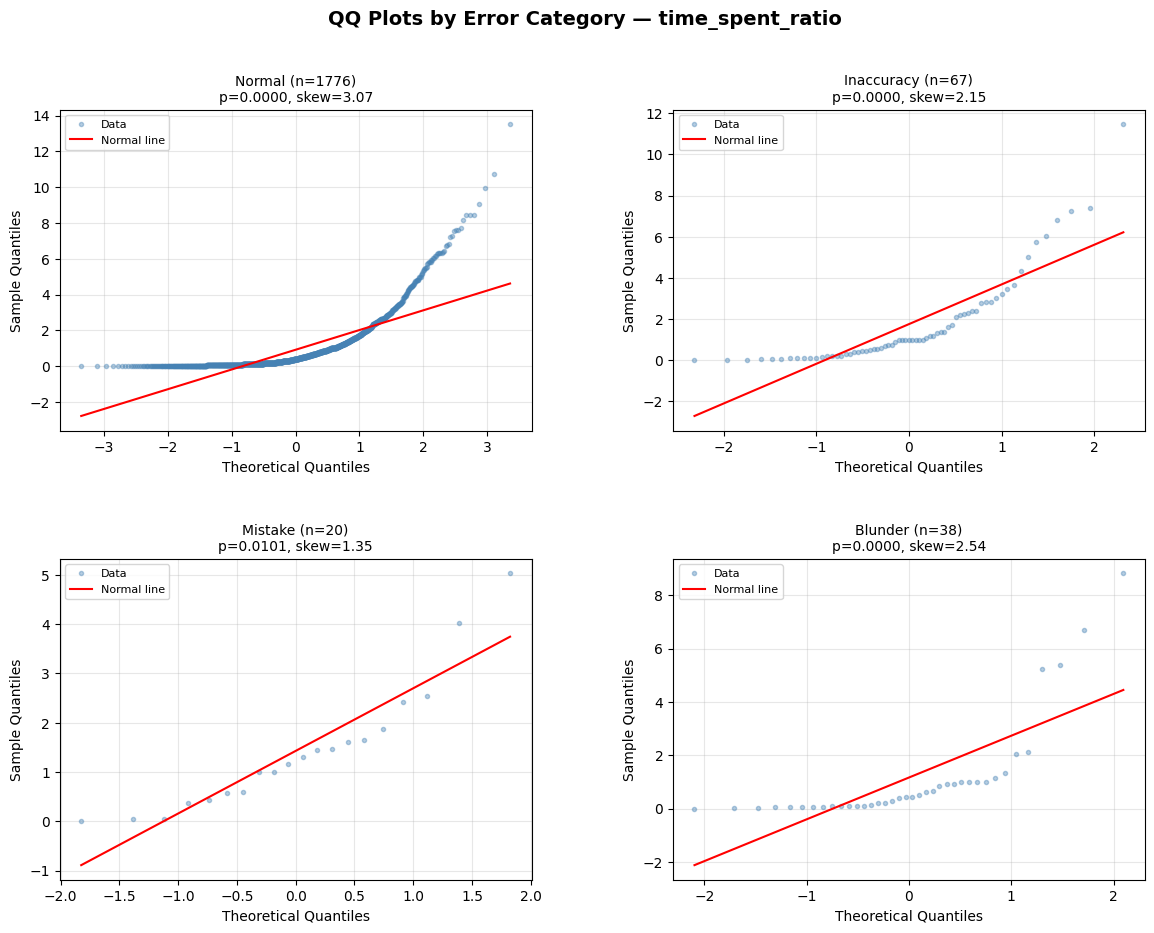


SUMMARY
Category          N     Stat    P-value     Skew     Kurt  Normal?
-----------------------------------------------------------------
Normal         1776   0.6537   0.000000   3.0729  13.0353 fail to reject
Inaccuracy       67   0.7411   0.000000   2.1515   5.1224 fail to reject
Mistake          20   0.8662   0.010087   1.3491   1.4856 fail to reject
Blunder          38   0.5885   0.000000   2.5421   5.6936 fail to reject


In [ ]:
from scipy import stats
import matplotlib.gridspec as gridspec

categories = ['Normal', 'Inaccuracy', 'Mistake', 'Blunder']
normality_results = {}

# QQ Plots
fig = plt.figure(figsize=(14, 10))
fig.suptitle("QQ Plots by Error Category — time_spent_ratio", fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

for idx, category in enumerate(categories):
    data = df[df['error_category'] == category]['time_spent_ratio'].dropna()
    n = len(data)

    stat, p = stats.shapiro(data)

    normality_results[category] = {
        'n': n,
        'statistic': stat,
        'p_value': p,
        'skewness': stats.skew(data),
        'kurtosis': stats.kurtosis(data)
    }

    # Print results
    print(f"{category} (n={n}):")
    print(f"  Shapiro-Wilk statistic: {stat:.6f}")
    print(f"  P-value:  {p:.6f}")
    print(f"  Skewness: {stats.skew(data):.4f}  (|>1| = notably skewed)")
    print(f"  Kurtosis: {stats.kurtosis(data):.4f}  (|>1| = notably heavy/light tailed)")
    if p < 0.05:
        print(f"REJECT null hypothesis: Not normally distributed — check QQ plot for severity")
    else:
        print(f"FAIL TO REJECT null hypothesis: Consistent with normality")
    print()

    # QQ plot
    ax = fig.add_subplot(gs[idx])
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")
    ax.plot(osm, osr, 'o', alpha=0.4, markersize=3, color='steelblue', label='Data')
    ax.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5, label='Normal line')
    ax.set_title(f"{category} (n={n})\np={p:.4f}, skew={stats.skew(data):.2f}", fontsize=10)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.show()

#Summary 
all_normal = all(r['p_value'] >= 0.05 for r in normality_results.values() if not np.isnan(r['p_value']))

print("\nSUMMARY")
print(f"{'Category':<12} {'N':>6} {'Stat':>8} {'P-value':>10} {'Skew':>8} {'Kurt':>8} {'Normal?':>8}")
print("-" * 65)
for cat, r in normality_results.items():
    normal_str = "reject" if r['p_value'] >= 0.05 else "fail to reject"
    print(f"{cat:<12} {r['n']:>6} {r['statistic']:>8.4f} {r['p_value']:>10.6f} "
          f"{r['skewness']:>8.4f} {r['kurtosis']:>8.4f} {normal_str:>8}")


Levene's Test for Homogeneity of Variance
* Null hypothesis: Variances are equal across groups
* Alternate hypothesis: Variances are NOT equal across groups

In [ ]:
groups_data = [
    df[df['error_category'] == cat]['time_spent_ratio'].dropna()
    for cat in ['Normal', 'Inaccuracy', 'Mistake', 'Blunder']
]

levene_stat, levene_p = stats.levene(*groups_data)
print(f"Levene statistic: {levene_stat:.6f}")
print(f"P-value: {levene_p:.6f}")

if levene_p < 0.05:
    print(f"REJECT null hypothesis: Variances are NOT equal (p < 0.05)")
    print("Use Welch's ANOVA or Kruskal-Wallis")
    equal_var = False
else:
    print(f"FAIL TO REJECT null hypothesis: Variances appear equal (p >= 0.05)")
    print("Standard ANOVA is appropriate")
    equal_var = True

Levene statistic: 5.127248
P-value: 0.001560
REJECT null hypothesis: Variances are NOT equal (p < 0.05)
Use Welch's ANOVA or Kruskal-Wallis


Use the Kruskal-Wallis Test (Non-parametric alternative) 
* Null hypothesis: Distribution of time_spent_ratio is equal across all error types
* Alternate hypothesis: At least one group's distribution is stochastically different
* Note: Interpreted as median differences assuming similar group shapes

In [ ]:
kw_stat, kw_p = stats.kruskal(*groups_data)

print(f"Kruskal-Wallis H-statistic: {kw_stat:.6f}")
print(f"P-value: {kw_p:.6f}")

if kw_p < 0.05:
    print(f"\nREJECT null hypothesis: (p = {kw_p:.6f} < 0.05)")
    print("  Conclusion: Median time_spent_ratio DIFFERS across error types")
else:
    print(f"\nFAIL TO REJECT null hypothesis: (p = {kw_p:.6f} >= 0.05)")
    print("  Conclusion: No significant difference in median time_spent_ratio")

# Calculate effect size (epsilon-squared for Kruskal-Wallis)
n = len(df)
k = 4  # number of groups
epsilon_squared = (kw_stat - k + 1) / (n - k)

print(f"\nEffect Size: {epsilon_squared:.6f}")
if epsilon_squared < 0.01:
    effect_kw = "negligible"
elif epsilon_squared < 0.08:
    effect_kw = "small"
elif epsilon_squared < 0.26:
    effect_kw = "medium"
else:
    effect_kw = "large"
print(f"  Interpretation: {effect_kw} effect")

Kruskal-Wallis H-statistic: 21.758973
P-value: 0.000073

REJECT null hypothesis: (p = 0.000073 < 0.05)
  Conclusion: Median time_spent_ratio DIFFERS across error types

Effect Size: 0.009889
  Interpretation: negligible effect


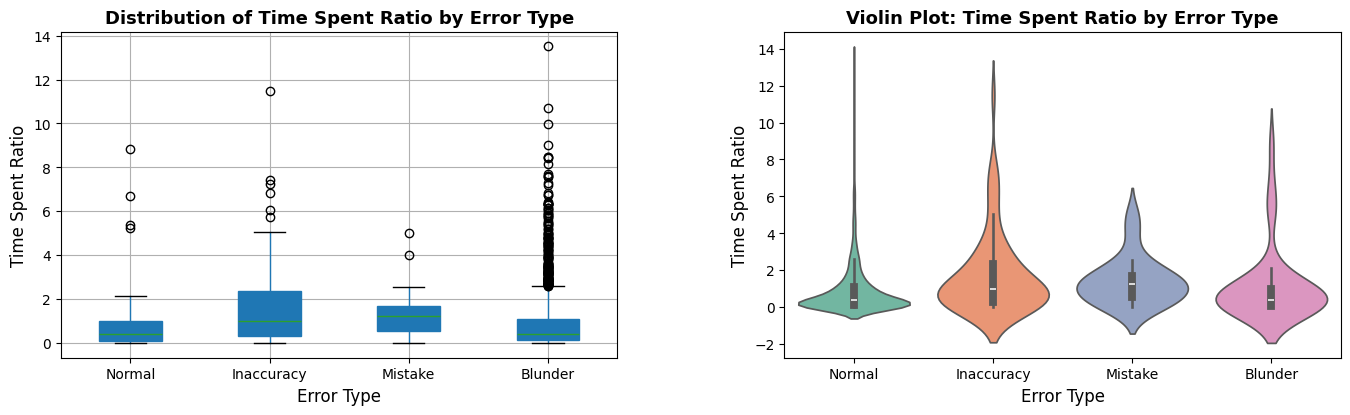

In [57]:
# Visualizations

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Plot 1: Box plot
ax1 = fig.add_subplot(gs[0, 0])
order = ['Normal', 'Inaccuracy', 'Mistake', 'Blunder']
df.boxplot(column='time_spent_ratio', by='error_category', ax=ax1, 
                 positions=range(len(order)), patch_artist=True)
ax1.set_xticklabels(order)
ax1.set_xlabel('Error Type', fontsize=12)
ax1.set_ylabel('Time Spent Ratio', fontsize=12)
ax1.set_title('Distribution of Time Spent Ratio by Error Type', fontsize=13, fontweight='bold')
plt.sca(ax1)
plt.xticks(rotation=0)
ax1.get_figure().suptitle('')  # Remove automatic title

# Plot 2: Violin plot
ax2 = fig.add_subplot(gs[0, 1])
sns.violinplot(data=df, x='error_category', y='time_spent_ratio', 
               order=order, ax=ax2, palette='Set2')
ax2.set_xlabel('Error Type', fontsize=12)
ax2.set_ylabel('Time Spent Ratio', fontsize=12)
ax2.set_title('Violin Plot: Time Spent Ratio by Error Type', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=0)


In [58]:
df.columns

Index(['game_id', 'move_number', 'increment_sec', 'time_left_sec',
       'time_spent_sec', 'time_left_ratio', 'time_spent_ratio', 'eval', 'mate',
       'eval_volatility', 'pieces_remaining', 'material_density',
       'num_minor_pieces', 'num_rooks', 'num_queens', 'num_pawns',
       'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'is_mate_threat', 'is_checkmate', 'is_inaccuracy', 'is_mistake',
       'is_blunder', 'eval_unified', 'eval_volatility_norm',
       'time_pressure_norm', 'complexity_material_norm',
       'material_time_pressure_int', 'time_eval_volatility_int',
       'move_number_norm', 'cumulative_time_pressure', 'late_endgame_int',
       'color_white', 'time_control_10+1', 'ti

Create Quartile Bins for complexity material norm

In [ ]:
df['complexity_quartile'] = pd.qcut(
    df['complexity_material_norm'],
    q=4,
    labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'],
    duplicates='drop'
)

quartile_boundaries = df.groupby('complexity_quartile')['complexity_material_norm'].agg(['min', 'max', 'mean', 'count'])
print("\nQuartile Boundaries:")
print(quartile_boundaries.round(2))

# Error rates by quartile
error_cols = ['is_inaccuracy', 'is_mistake', 'is_blunder']
print("\nError Rates by Complexity Quartile:")
print(df.groupby('complexity_quartile')[error_cols].mean().round(4) * 100)


Quartile Boundaries:
                      min   max  mean  count
complexity_quartile                         
Q1 (Low)             0.09  0.32  0.23    491
Q2                   0.33  0.65  0.49    481
Q3                   0.67  0.95  0.84    520
Q4 (High)            0.96  1.00  0.99    409

Error Rates by Complexity Quartile:
                     is_inaccuracy  is_mistake  is_blunder
complexity_quartile                                       
Q1 (Low)                      3.46        1.02        3.87
Q2                            4.37        0.83        2.70
Q3                            5.38        2.12        1.15
Q4 (High)                     0.24        0.00        0.00


Calculate Error Rates by Quartile 

In [ ]:
error_rates = df.groupby('complexity_quartile').agg({
    'is_inaccuracy': ['sum', 'mean'],
    'is_mistake': ['sum', 'mean'],
    'is_blunder': ['sum', 'mean'],
    'move_number': 'count'
}).round(4)

error_rates.columns = [
    'Inaccuracy_Count', 'Inaccuracy_Rate',
    'Mistake_Count', 'Mistake_Rate',
    'Blunder_Count', 'Blunder_Rate',
    'Total_Moves'
]

print("\n", error_rates)

# Convert to percentages
rates_pct = error_rates.copy()
for col in ['Inaccuracy_Rate', 'Mistake_Rate', 'Blunder_Rate']:
    rates_pct[col] = rates_pct[col] * 100

print("\nError Rates (%) by Complexity Quartile")
print(rates_pct[['Inaccuracy_Rate', 'Mistake_Rate', 'Blunder_Rate', 'Total_Moves']].round(2))



                      Inaccuracy_Count  Inaccuracy_Rate  Mistake_Count  \
complexity_quartile                                                     
Q1 (Low)                           17           0.0346              5   
Q2                                 21           0.0437              4   
Q3                                 28           0.0538             11   
Q4 (High)                           1           0.0024              0   

                     Mistake_Rate  Blunder_Count  Blunder_Rate  Total_Moves  
complexity_quartile                                                          
Q1 (Low)                   0.0102             19        0.0387          491  
Q2                         0.0083             13        0.0270          481  
Q3                         0.0212              6        0.0115          520  
Q4 (High)                  0.0000              0        0.0000          409  

Error Rates (%) by Complexity Quartile
                     Inaccuracy_Rate  Mistake_Rate 

MANN-WHITNEY U TEST: material complexity to error type
* Null hypothesis: Complexity distribution is equal between error group and non-error group
* Alternate hypo: Complexity distribution differs between groups
* Note: Tests each error type independently against all other moves

In [ ]:
from scipy import stats

error_types = ['is_inaccuracy', 'is_mistake', 'is_blunder']
mw_results = {}

for error_col in error_types:
    category = error_col.replace('is_', '').capitalize()
    
    error_group    = df[df[error_col] == 1]['complexity_material_norm'].dropna()
    non_error_group = df[df[error_col] == 0]['complexity_material_norm'].dropna()
    
    stat, p = stats.mannwhitneyu(error_group, non_error_group, alternative='two-sided')
    
    # Effect size: rank-biserial correlation
    n1, n2 = len(error_group), len(non_error_group)
    r = 1 - (2 * stat) / (n1 * n2)
    
    mw_results[category] = {'n_error': n1, 'n_non_error': n2, 'stat': stat, 'p_value': p, 'r': r}
    
    print(f"{category} (n={n1}) vs Non-{category} (n={n2}):")
    print(f"  Median complexity - {category}: {error_group.median():.4f} | Non-{category}: {non_error_group.median():.4f}")
    print(f"  Mann-Whitney U:  {stat:.4f}")
    print(f"  P-value:         {p:.6f}")
    print(f"  Effect size (r): {abs(r):.4f}  ", end="")
    
    r_abs = abs(r)
    if r_abs < 0.1:
        print("(negligible)")
    elif r_abs < 0.3:
        print("(small)")
    elif r_abs < 0.5:
        print("(medium)")
    else:
        print("(large)")
    
    if p < 0.05:
        direction = "higher" if error_group.median() > non_error_group.median() else "lower"
        print(f"REJECT null hypothesis: {category}s occur at significantly {direction} complexity (p < 0.05)")
    else:
        print(f"FAIL TO REJECT null hypothesis: No significant complexity difference for {category}s")
    print()

# Summary table
print("=" * 80)
print("\nSUMMARY")
print(f"{'Category':<14} {'N (error)':>10} {'Median (error)':>15} {'Median (non)':>13} {'U-stat':>10} {'P-value':>10} {'r':>8} {'Sig':>5}")
print("-" * 90)
for cat, r in mw_results.items():
    error_group = df[df[f'is_{cat.lower()}'] == 1]['complexity_material_norm'].dropna()
    non_error_group = df[df[f'is_{cat.lower()}'] == 0]['complexity_material_norm'].dropna()
    sig = "reject null" if r['p_value'] < 0.05 else "fail to reject null"
    print(f"{cat:<14} {r['n_error']:>10} {error_group.median():>15.4f} {non_error_group.median():>13.4f} "
          f"{r['stat']:>10.2f} {r['p_value']:>10.6f} {r['r']:>8.4f} {sig:>5}")

Inaccuracy (n=67) vs Non-Inaccuracy (n=1834):
  Median complexity - Inaccuracy: 0.5897 | Non-Inaccuracy: 0.6538
  Mann-Whitney U:  53464.5000
  P-value:         0.070146
  Effect size (r): 0.1298  (small)
FAIL TO REJECT null hypothesis: No significant complexity difference for Inaccuracys

Mistake (n=20) vs Non-Mistake (n=1881):
  Median complexity - Mistake: 0.7372 | Non-Mistake: 0.6410
  Mann-Whitney U:  17645.5000
  P-value:         0.632817
  Effect size (r): 0.0619  (negligible)
FAIL TO REJECT null hypothesis: No significant complexity difference for Mistakes

Blunder (n=38) vs Non-Blunder (n=1863):
  Median complexity - Blunder: 0.3269 | Non-Blunder: 0.6538
  Mann-Whitney U:  19287.0000
  P-value:         0.000001
  Effect size (r): 0.4551  (medium)
REJECT null hypothesis: Blunders occur at significantly lower complexity (p < 0.05)


SUMMARY
Category        N (error)  Median (error)  Median (non)     U-stat    P-value        r   Sig
-----------------------------------------------

Observations
* Makes sense, blunders tend to occur when the material is less complex, supposedly in an endgame where more chance for +3 eval changes
* whereas in more complex positions such as in opening /middlegame, grave errors less likely to occur, would be more inaccuracies/mistakes. 

Create Quartile Bins for eval_volatility norm

In [ ]:
df['volatility_quartile'] = pd.qcut(
    df['eval_volatility'],
    q=4,
    labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'],
    duplicates='drop'
)

quartile_boundaries = df.groupby('volatility_quartile')['eval_volatility'].agg(['min', 'max', 'mean', 'count'])
print("\nQuartile Boundaries:")
print(quartile_boundaries.round(2))

# Error rates by quartile
error_cols = ['is_inaccuracy', 'is_mistake', 'is_blunder']
print("\nError Rates by Volatility Quartile:")
print(df.groupby('volatility_quartile')[error_cols].mean().round(4) * 100)


Quartile Boundaries:
                       min      max    mean  count
volatility_quartile                               
Q1 (Low)              0.00     7.36    3.35    454
Q2                    7.41    19.60   12.85    453
Q3                   19.65    49.49   31.94    453
Q4 (High)            49.56  4097.18  549.73    453

Error Rates by Volatility Quartile:
                     is_inaccuracy  is_mistake  is_blunder
volatility_quartile                                       
Q1 (Low)                      0.00        0.00        0.00
Q2                            0.00        0.00        0.00
Q3                            1.32        0.00        0.00
Q4 (High)                    13.47        4.42        8.39


Calculate Error Rates by Quartile 

In [ ]:
error_rates = df.groupby('volatility_quartile').agg({
    'is_inaccuracy': ['sum', 'mean'],
    'is_mistake': ['sum', 'mean'],
    'is_blunder': ['sum', 'mean'],
    'move_number': 'count'
}).round(4)

error_rates.columns = [
    'Inaccuracy_Count', 'Inaccuracy_Rate',
    'Mistake_Count', 'Mistake_Rate',
    'Blunder_Count', 'Blunder_Rate',
    'Total_Moves'
]

print("\n", error_rates)

# Convert to percentages
rates_pct = error_rates.copy()
for col in ['Inaccuracy_Rate', 'Mistake_Rate', 'Blunder_Rate']:
    rates_pct[col] = rates_pct[col] * 100

print("\nError Rates (%) by Volatility Quartile")
print(rates_pct[['Inaccuracy_Rate', 'Mistake_Rate', 'Blunder_Rate', 'Total_Moves']].round(2))



                      Inaccuracy_Count  Inaccuracy_Rate  Mistake_Count  \
volatility_quartile                                                     
Q1 (Low)                            0           0.0000              0   
Q2                                  0           0.0000              0   
Q3                                  6           0.0132              0   
Q4 (High)                          61           0.1347             20   

                     Mistake_Rate  Blunder_Count  Blunder_Rate  Total_Moves  
volatility_quartile                                                          
Q1 (Low)                   0.0000              0        0.0000          454  
Q2                         0.0000              0        0.0000          453  
Q3                         0.0000              0        0.0000          453  
Q4 (High)                  0.0442             38        0.0839          453  

Error Rates (%) by Volatility Quartile
                     Inaccuracy_Rate  Mistake_Rate 

MANN-WHITNEY U TEST: eval volatility to error type
* null hypothesis: volatility distribution is equal between error group and non-error group
* alternate hypo: volatility distribution differs between groups
* Note: Tests each error type independently against all other moves

In [ ]:
from scipy import stats

error_types = ['is_inaccuracy', 'is_mistake', 'is_blunder']
mw_results = {}

for error_col in error_types:
    category = error_col.replace('is_', '').capitalize()
    
    error_group    = df[df[error_col] == 1]['eval_volatility'].dropna()
    non_error_group = df[df[error_col] == 0]['eval_volatility'].dropna()
    
    stat, p = stats.mannwhitneyu(error_group, non_error_group, alternative='two-sided')
    
    # Effect size: rank-biserial correlation
    n1, n2 = len(error_group), len(non_error_group)
    r = 1 - (2 * stat) / (n1 * n2)
    
    mw_results[category] = {'n_error': n1, 'n_non_error': n2, 'stat': stat, 'p_value': p, 'r': r}
    
    print(f"{category} (n={n1}) vs Non-{category} (n={n2}):")
    print(f"  Median volatility - {category}: {error_group.median():.4f} | Non-{category}: {non_error_group.median():.4f}")
    print(f"  Mann-Whitney U:  {stat:.4f}")
    print(f"  P-value:         {p:.6f}")
    print(f"  Effect size (r): {abs(r):.4f}  ", end="")
    
    r_abs = abs(r)
    if r_abs < 0.1:
        print("(negligible)")
    elif r_abs < 0.3:
        print("(small)")
    elif r_abs < 0.5:
        print("(medium)")
    else:
        print("(large)")
    
    if p < 0.05:
        direction = "higher" if error_group.median() > non_error_group.median() else "lower"
        print(f"REJECT null hypothesis: {category}s occur at significantly {direction} volatility (p < 0.05)")
    else:
        print(f"FAIL TO REJECT null hypothesis: No significant volatility difference for {category}s")
    print()

# Summary table
print("=" * 80)
print("\nSUMMARY")
print(f"{'Category':<14} {'N (error)':>10} {'Median (error)':>15} {'Median (non)':>13} {'U-stat':>10} {'P-value':>10} {'r':>8} {'Sig':>5}")
print("-" * 90)
for cat, r in mw_results.items():
    error_group = df[df[f'is_{cat.lower()}'] == 1]['eval_volatility'].dropna()
    non_error_group = df[df[f'is_{cat.lower()}'] == 0]['eval_volatility'].dropna()
    sig = "reject null" if r['p_value'] < 0.05 else "fail to reject null"
    print(f"{cat:<14} {r['n_error']:>10} {error_group.median():>15.4f} {non_error_group.median():>13.4f} "
          f"{r['stat']:>10.2f} {r['p_value']:>10.6f} {r['r']:>8.4f} {sig:>5}")

Inaccuracy (n=67) vs Non-Inaccuracy (n=1746):
  Median volatility - Inaccuracy: 76.2408 | Non-Inaccuracy: 18.4451
  Mann-Whitney U:  97510.5000
  P-value:         0.000000
  Effect size (r): 0.6671  (large)
REJECT null hypothesis: Inaccuracys occur at significantly higher volatility (p < 0.05)

Mistake (n=20) vs Non-Mistake (n=1793):
  Median volatility - Mistake: 133.0542 | Non-Mistake: 19.3620
  Mann-Whitney U:  32196.0000
  P-value:         0.000000
  Effect size (r): 0.7956  (large)
REJECT null hypothesis: Mistakes occur at significantly higher volatility (p < 0.05)

Blunder (n=38) vs Non-Blunder (n=1775):
  Median volatility - Blunder: 248.1400 | Non-Blunder: 19.2007
  Mann-Whitney U:  64011.0000
  P-value:         0.000000
  Effect size (r): 0.8980  (large)
REJECT null hypothesis: Blunders occur at significantly higher volatility (p < 0.05)


SUMMARY
Category        N (error)  Median (error)  Median (non)     U-stat    P-value        r   Sig
--------------------------------------

Observations
* Across all inaccuracies, mistakes and blunders, all are more concentrated when the volatility is high

In [ ]:
df_clean = df[df['eval_volatility'].notna()].copy()

blunders         = df_clean[df_clean['is_blunder'] == 1]['eval_volatility']
non_blunders     = df_clean[df_clean['is_blunder'] == 0]['eval_volatility']
mistakes         = df_clean[df_clean['is_mistake'] == 1]['eval_volatility']
non_mistakes     = df_clean[df_clean['is_mistake'] == 0]['eval_volatility']
inaccuracies     = df_clean[df_clean['is_inaccuracy'] == 1]['eval_volatility']
non_inaccuracies = df_clean[df_clean['is_inaccuracy'] == 0]['eval_volatility']

print(f"\nSample sizes:")
print(f"  Blunders:         {len(blunders)}")
print(f"  Non-blunders:     {len(non_blunders)}")
print(f"  Mistakes:         {len(mistakes)}")
print(f"  Non-mistakes:     {len(non_mistakes)}")
print(f"  Inaccuracies:     {len(inaccuracies)}")
print(f"  Non-inaccuracies: {len(non_inaccuracies)}")
print(f"  Total (with eval_volatility): {len(df_clean)}")




Sample sizes:
  Blunders:         38
  Non-blunders:     1775
  Mistakes:         20
  Non-mistakes:     1793
  Inaccuracies:     67
  Non-inaccuracies: 1746
  Total (with eval_volatility): 1813


In [ ]:
desc_stats = pd.DataFrame({
    'Group': ['Blunders', 'Non-Blunders', 'Mistakes', 'Non-Mistakes', 'Inaccuracies', 'Non-Inaccuracies'],
    'N':      [len(blunders), len(non_blunders), len(mistakes), len(non_mistakes), len(inaccuracies), len(non_inaccuracies)],
    'Mean':   [blunders.mean(), non_blunders.mean(), mistakes.mean(), non_mistakes.mean(), inaccuracies.mean(), non_inaccuracies.mean()],
    'Median': [blunders.median(), non_blunders.median(), mistakes.median(), non_mistakes.median(), inaccuracies.median(), non_inaccuracies.median()],
    'Std':    [blunders.std(), non_blunders.std(), mistakes.std(), non_mistakes.std(), inaccuracies.std(), non_inaccuracies.std()],
    'Min':    [blunders.min(), non_blunders.min(), mistakes.min(), non_mistakes.min(), inaccuracies.min(), non_inaccuracies.min()],
    'Max':    [blunders.max(), non_blunders.max(), mistakes.max(), non_mistakes.max(), inaccuracies.max(), non_inaccuracies.max()],
})
print("\n", desc_stats.round(4).to_string(index=False))


            Group    N     Mean   Median      Std      Min       Max
        Blunders   38 643.8072 248.1400 822.1953 128.2887 3154.7305
    Non-Blunders 1775 138.8030  19.2007 556.7268   0.0000 4097.1785
        Mistakes   20 134.3362 133.0542  28.4495  90.2995  206.0679
    Non-Mistakes 1793 149.5556  19.3620 571.0277   0.0000 4097.1785
    Inaccuracies   67  83.6669  76.2408  38.6856  41.5291  273.8223
Non-Inaccuracies 1746 151.9097  18.4451 578.4789   0.0000 4097.1785


NORMALITY TESTS (Shapiro-Wilk)
* Null hypothesis: Data is normally distributed
* alternate hypothesis: Data is NOT normally distributed

In [ ]:
normality_decisions = {}
test_groups = [
    ('Blunders',         blunders),
    ('Non-Blunders',     non_blunders),
    ('Mistakes',         mistakes),
    ('Non-Mistakes',     non_mistakes),
    ('Inaccuracies',     inaccuracies),
    ('Non-Inaccuracies', non_inaccuracies),
]

for name, data in test_groups:

    test_data = data
    note = f"n={len(data)}"

    stat, p = stats.shapiro(test_data)
    normality_decisions[name] = p >= 0.05

    print(f"{name} ({note}):")
    print(f"  Shapiro-Wilk statistic: {stat:.6f}")
    print(f"  P-value: {p:.6f}")
    if p < 0.05:
        print(f"REJECT null hypothesis: Not normally distributed")
    else:
        print(f"FAIL TO REJECT null hypothesis: Consistent with normality")
    print()

# Test selection per comparison
print("=" * 80)
print("\nTEST SELECTION")
test_pairs = [
    ('Blunders',     'Non-Blunders'),
    ('Mistakes',     'Non-Mistakes'),
    ('Inaccuracies', 'Non-Inaccuracies'),
]
for error, non_error in test_pairs:
    both_normal = normality_decisions[error] and normality_decisions[non_error]
    test = "t-test" if both_normal else "Mann-Whitney U"
    reason = "both normal" if both_normal else "at least one group non-normal"
    print(f"  {error} vs {non_error}: → {test} ({reason})")

Blunders (n=38):
  Shapiro-Wilk statistic: 0.629104
  P-value: 0.000000
REJECT null hypothesis: Not normally distributed

Non-Blunders (n=1775):
  Shapiro-Wilk statistic: 0.233908
  P-value: 0.000000
REJECT null hypothesis: Not normally distributed

Mistakes (n=20):
  Shapiro-Wilk statistic: 0.966938
  P-value: 0.689369
FAIL TO REJECT null hypothesis: Consistent with normality

Non-Mistakes (n=1793):
  Shapiro-Wilk statistic: 0.252614
  P-value: 0.000000
REJECT null hypothesis: Not normally distributed

Inaccuracies (n=67):
  Shapiro-Wilk statistic: 0.791620
  P-value: 0.000000
REJECT null hypothesis: Not normally distributed

Non-Inaccuracies (n=1746):
  Shapiro-Wilk statistic: 0.255520
  P-value: 0.000000
REJECT null hypothesis: Not normally distributed


TEST SELECTION
  Blunders vs Non-Blunders: → Mann-Whitney U (at least one group non-normal)
  Mistakes vs Non-Mistakes: → Mann-Whitney U (at least one group non-normal)
  Inaccuracies vs Non-Inaccuracies: → Mann-Whitney U (at least 

Mann-Whitney U Test (Non-parametric) 
* Null hypo: Distributions are equal between error group and non-error group
* Alternate hypo: Distributions differ between groups

In [ ]:
mw_pairs = [
    ('Blunders',     'Non-Blunders',     blunders,     non_blunders),
    ('Mistakes',     'Non-Mistakes',     mistakes,     non_mistakes),
    ('Inaccuracies', 'Non-Inaccuracies', inaccuracies, non_inaccuracies),
]

for error, non_error, error_data, non_error_data in mw_pairs:
    n1, n2 = len(error_data), len(non_error_data)
    u_stat, u_p = stats.mannwhitneyu(error_data, non_error_data, alternative='two-sided')

    # Rank-biserial correlation
    r = 1 - (2 * u_stat) / (n1 * n2)
    r_abs = abs(r)
    if r_abs < 0.1:
        effect_interpretation = "negligible"
    elif r_abs < 0.3:
        effect_interpretation = "small"
    elif r_abs < 0.5:
        effect_interpretation = "medium"
    else:
        effect_interpretation = "large"

    # Approximate 95% CI for rank-biserial r
    se_r = np.sqrt((n1 + n2 + 1) / (3 * n1 * n2))
    ci_lower = r - 1.96 * se_r
    ci_upper = r + 1.96 * se_r

    print(f"{error} (n={n1}) vs {non_error} (n={n2}):")
    print(f"  Median — {error}: {error_data.median():.4f} | {non_error}: {non_error_data.median():.4f}")
    print(f"  U-statistic: {u_stat:.2f}")
    print(f"  P-value:     {u_p:.6f}")

    if u_p < 0.05:
        direction = "higher" if error_data.median() > non_error_data.median() else "lower"
        print(f"REJECT null hypothesis (p < 0.05): {error} have significantly {direction} eval_volatility")
    else:
        print(f"FAIL TO REJECT null hypothesis (p >= 0.05): No significant difference detected")

    print(f"\n  Effect Size (rank-biserial r): {r:.4f} — {effect_interpretation}")
    print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
    if r > 0:
        print(f"  Direction: {error} tend to have higher volatility than {non_error}")
    else:
        print(f"  Direction: {error} tend to have lower volatility than {non_error}")
    print()

Blunders (n=38) vs Non-Blunders (n=1775):
  Median — Blunders: 248.1400 | Non-Blunders: 19.2007
  U-statistic: 64011.00
  P-value:     0.000000
REJECT null hypothesis (p < 0.05): Blunders have significantly higher eval_volatility

  Effect Size (rank-biserial r): -0.8980 — large
  95% CI: [-1.0836, -0.7125]
  Direction: Blunders tend to have lower volatility than Non-Blunders

Mistakes (n=20) vs Non-Mistakes (n=1793):
  Median — Mistakes: 133.0542 | Non-Mistakes: 19.3620
  U-statistic: 32196.00
  P-value:     0.000000
REJECT null hypothesis (p < 0.05): Mistakes have significantly higher eval_volatility

  Effect Size (rank-biserial r): -0.7956 — large
  95% CI: [-1.0502, -0.5411]
  Direction: Mistakes tend to have lower volatility than Non-Mistakes

Inaccuracies (n=67) vs Non-Inaccuracies (n=1746):
  Median — Inaccuracies: 76.2408 | Non-Inaccuracies: 18.4451
  U-statistic: 97510.50
  P-value:     0.000000
REJECT null hypothesis (p < 0.05): Inaccuracies have significantly higher eval_vo

In [71]:
df.columns

Index(['game_id', 'move_number', 'increment_sec', 'time_left_sec',
       'time_spent_sec', 'time_left_ratio', 'time_spent_ratio', 'eval', 'mate',
       'eval_volatility', 'pieces_remaining', 'material_density',
       'num_minor_pieces', 'num_rooks', 'num_queens', 'num_pawns',
       'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'is_mate_threat', 'is_checkmate', 'is_inaccuracy', 'is_mistake',
       'is_blunder', 'eval_unified', 'eval_volatility_norm',
       'time_pressure_norm', 'complexity_material_norm',
       'material_time_pressure_int', 'time_eval_volatility_int',
       'move_number_norm', 'cumulative_time_pressure', 'late_endgame_int',
       'color_white', 'time_control_10+1', 'ti

Complexity x Time Pressure Interaction on Blunders
* Null hypothesis: material_time_pressure_int has no association with is_blunder

In [80]:
from scipy import stats

df_clean = df[['material_time_pressure_int', 'is_blunder']].dropna()

corr, p = stats.pointbiserialr(df_clean['is_blunder'], df_clean['material_time_pressure_int'])

print(f"\nPoint-Biserial Correlation: {corr:.4f}")
print(f"P-value: {p:.6f}")
print(f"\nMean interaction — Blunders:     {df_clean[df_clean['is_blunder']==1]['material_time_pressure_int'].mean():.4f}")
print(f"Mean interaction — Non-Blunders: {df_clean[df_clean['is_blunder']==0]['material_time_pressure_int'].mean():.4f}")

if p < 0.05:
    direction = "positively" if corr > 0 else "negatively"
    print(f"\nREJECT null hypo: material_time_pressure_int is {direction} associated with blunders (p < 0.05)")
else:
    print(f"\nFAIL TO REJECT null hypo: No significant association detected")


Point-Biserial Correlation: 0.0661
P-value: 0.003915

Mean interaction — Blunders:     0.2859
Mean interaction — Non-Blunders: 0.2106

REJECT null hypo: material_time_pressure_int is positively associated with blunders (p < 0.05)


Time pressure and eval volatility interaction

Time x Eval Volatility Interaction on Error Types
* Null hypothesis: 'time_eval_volatility_int' distribution is equal across error/non-error moves

In [81]:
df_clean = df[['time_eval_volatility_int', 'is_blunder', 'is_mistake', 'is_inaccuracy']].dropna()

for error_col, label in [('is_blunder', 'Blunders'), ('is_mistake', 'Mistakes'), ('is_inaccuracy', 'Inaccuracies')]:
    error_group     = df_clean[df_clean[error_col] == 1]['time_eval_volatility_int']
    non_error_group = df_clean[df_clean[error_col] == 0]['time_eval_volatility_int']
    
    u_stat, p = stats.mannwhitneyu(error_group, non_error_group, alternative='two-sided')
    n1, n2 = len(error_group), len(non_error_group)
    r = 1 - (2 * u_stat) / (n1 * n2)

    print(f"\n{label} (n={n1}) vs Non-{label} (n={n2}):")
    print(f"  Median — {label}: {error_group.median():.4f} | Non-{label}: {non_error_group.median():.4f}")
    print(f"  U-statistic: {u_stat:.2f} | P-value: {p:.6f} | r: {r:.4f}")
    if p < 0.05:
        direction = "higher" if error_group.median() > non_error_group.median() else "lower"
        print(f"  REJECT null hypo: {label} occur at significantly {direction} time x volatility interaction")
    else:
        print(f"  FAIL TO REJECT null hypo: No significant difference")


Blunders (n=38) vs Non-Blunders (n=1863):
  Median — Blunders: 0.7808 | Non-Blunders: 0.0225
  U-statistic: 67772.00 | P-value: 0.000000 | r: -0.9146
  REJECT null hypo: Blunders occur at significantly higher time x volatility interaction

Mistakes (n=20) vs Non-Mistakes (n=1881):
  Median — Mistakes: 0.3160 | Non-Mistakes: 0.0233
  U-statistic: 32960.00 | P-value: 0.000000 | r: -0.7523
  REJECT null hypo: Mistakes occur at significantly higher time x volatility interaction

Inaccuracies (n=67) vs Non-Inaccuracies (n=1834):
  Median — Inaccuracies: 0.1671 | Non-Inaccuracies: 0.0215
  U-statistic: 99487.00 | P-value: 0.000000 | r: -0.6193
  REJECT null hypo: Inaccuracies occur at significantly higher time x volatility interaction


Late Game x Endgame Interaction on Error Concentration
* Null hypothesis: Error rate is independent of late_endgame_int

In [82]:
from scipy.stats import chi2_contingency

df_clean = df[['late_endgame_int', 'is_blunder', 'is_mistake', 'is_inaccuracy']].dropna()

# Bin into high/low at median
median_val = df_clean['late_endgame_int'].median()
df_clean['late_endgame_high'] = (df_clean['late_endgame_int'] > median_val).astype(int)

for error_col, label in [('is_blunder', 'Blunder'), ('is_mistake', 'Mistake'), ('is_inaccuracy', 'Inaccuracy')]:
    ct = pd.crosstab(df_clean['late_endgame_high'], df_clean[error_col])
    chi2, p, dof, expected = chi2_contingency(ct)

    # Check expected cell counts
    min_expected = expected.min()
    n = len(df_clean)
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

    print(f"\n{label}:")
    print(f"  Chi2: {chi2:.4f} | P-value: {p:.6f} | Cramer's V: {cramers_v:.4f}")
    if min_expected < 5:
        print(f"  Min expected cell count = {min_expected:.1f} (< 5, interpret cautiously)")
    if p < 0.05:
        print(f"  REJECT null hypo: {label} rate differs by late endgame interaction")
    else:
        print(f"  FAIL TO REJECT null hypo: No significant concentration in late endgame")


Blunder:
  Chi2: 23.5566 | P-value: 0.000001 | Cramer's V: 0.1113
  REJECT null hypo: Blunder rate differs by late endgame interaction

Mistake:
  Chi2: 0.3665 | P-value: 0.544911 | Cramer's V: 0.0139
  FAIL TO REJECT null hypo: No significant concentration in late endgame

Inaccuracy:
  Chi2: 0.2252 | P-value: 0.635140 | Cramer's V: 0.0109
  FAIL TO REJECT null hypo: No significant concentration in late endgame


Observation
* Makes sense that blunder rate increases in a late endgmae

In [77]:
df.columns

Index(['game_id', 'move_number', 'increment_sec', 'time_left_sec',
       'time_spent_sec', 'time_left_ratio', 'time_spent_ratio', 'eval', 'mate',
       'eval_volatility', 'pieces_remaining', 'material_density',
       'num_minor_pieces', 'num_rooks', 'num_queens', 'num_pawns',
       'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'is_mate_threat', 'is_checkmate', 'is_inaccuracy', 'is_mistake',
       'is_blunder', 'eval_unified', 'eval_volatility_norm',
       'time_pressure_norm', 'complexity_material_norm',
       'material_time_pressure_int', 'time_eval_volatility_int',
       'move_number_norm', 'cumulative_time_pressure', 'late_endgame_int',
       'color_white', 'time_control_10+1', 'ti

Player-Relative Time Abnormality (Per Game) on Error Rate
* Null Hypothesis: Time abnormality vs player's own game average does not differ across error types
* Z-score time_spent_sec relative to each player's average for that specific game
* avg_time_spent_per_move is already the per-game average for that player

In [83]:
df['time_zscore_game'] = (
    (df['time_spent_sec'] - df['avg_time_spent_per_move']) /
    df.groupby('game_id')['time_spent_sec'].transform('std')
)

df_clean = df[['time_zscore_game', 'is_blunder', 'is_mistake', 'is_inaccuracy']].dropna()

print(f"\ntime_zscore_game: mean={df_clean['time_zscore_game'].mean():.4f}, std={df_clean['time_zscore_game'].std():.4f}")
print("(z > 0 = spent more time than their avg for THIS game, z < 0 = less time than usual)\n")

for error_col, label in [('is_blunder', 'Blunders'), ('is_mistake', 'Mistakes'), ('is_inaccuracy', 'Inaccuracies')]:
    error_group     = df_clean[df_clean[error_col] == 1]['time_zscore_game']
    non_error_group = df_clean[df_clean[error_col] == 0]['time_zscore_game']

    u_stat, p = stats.mannwhitneyu(error_group, non_error_group, alternative='two-sided')
    n1, n2 = len(error_group), len(non_error_group)
    r = 1 - (2 * u_stat) / (n1 * n2)

    print(f"{label} (n={n1}) vs Non-{label} (n={n2}):")
    print(f"  Median z-score — {label}: {error_group.median():.4f} | Non-{label}: {non_error_group.median():.4f}")
    print(f"  U-statistic: {u_stat:.2f} | P-value: {p:.6f} | r: {r:.4f}")
    if p < 0.05:
        direction = "more" if error_group.median() > non_error_group.median() else "less"
        print(f"  ✓ REJECT H₀: {label} occur when player spends {direction} time than their average for this game")
    else:
        print(f"  ✗ FAIL TO REJECT H₀: No significant deviation from in-game time baseline")
    print()


time_zscore_game: mean=-0.0200, std=0.9889
(z > 0 = spent more time than their avg for THIS game, z < 0 = less time than usual)

Blunders (n=38) vs Non-Blunders (n=1863):
  Median z-score — Blunders: -0.3871 | Non-Blunders: -0.4085
  U-statistic: 36283.00 | P-value: 0.791512 | r: -0.0250
  ✗ FAIL TO REJECT H₀: No significant deviation from in-game time baseline

Mistakes (n=20) vs Non-Mistakes (n=1881):
  Median z-score — Mistakes: 0.1948 | Non-Mistakes: -0.4105
  U-statistic: 23794.50 | P-value: 0.041246 | r: -0.2650
  ✓ REJECT H₀: Mistakes occur when player spends more time than their average for this game

Inaccuracies (n=67) vs Non-Inaccuracies (n=1834):
  Median z-score — Inaccuracies: 0.0405 | Non-Inaccuracies: -0.4174
  U-statistic: 81877.50 | P-value: 0.000004 | r: -0.3327
  ✓ REJECT H₀: Inaccuracies occur when player spends more time than their average for this game



Obsercations
* for mistakes and inaccuracies, there is significance when players spend more time than their avg for the game